# Vis 1

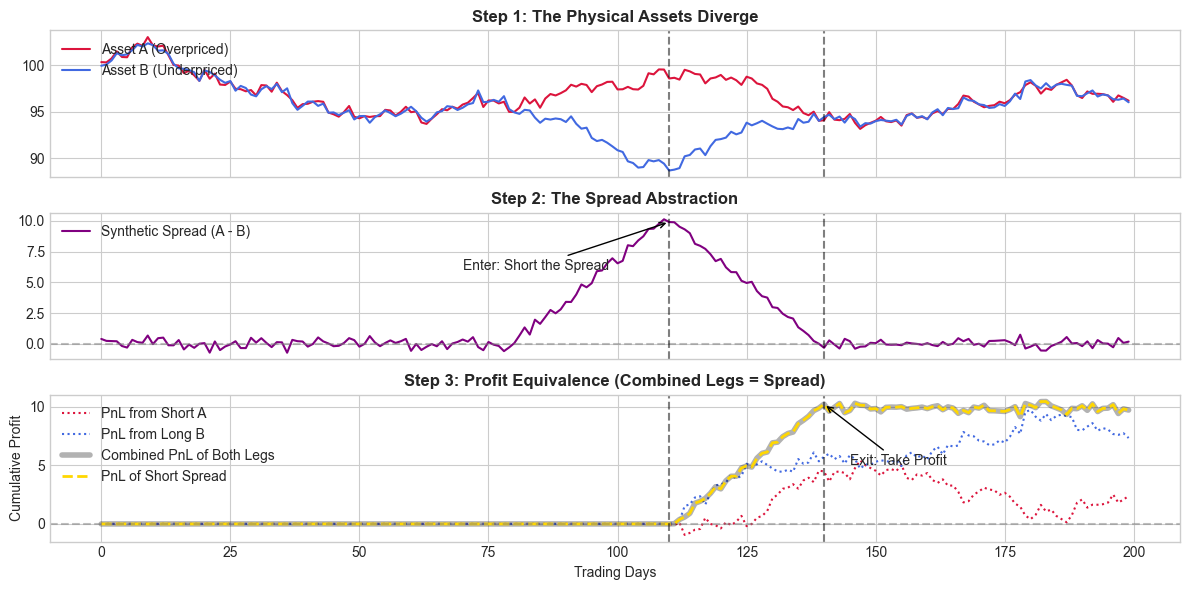

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Set plotting style for a clean, professional report look
plt.style.use('seaborn-v0_8-whitegrid')

# ---------------------------------------------------------
# 1. Simulate the Data
# ---------------------------------------------------------
np.random.seed(42)
n_steps = 200
time = np.arange(n_steps)

# Create a common random walk (the baseline market movement)
common_factor = np.cumsum(np.random.randn(n_steps) * 0.5) + 100

# Create Asset A and Asset B (highly correlated, tracking the common factor)
asset_a = common_factor + np.random.randn(n_steps) * 0.2
asset_b = common_factor + np.random.randn(n_steps) * 0.2

# Force a divergence (Spread Blowout) from day 80 to day 110
divergence = np.zeros(n_steps)
divergence[80:110] = np.linspace(0, 5, 30)
# Force a mean-reversion from day 110 to day 140
divergence[110:140] = np.linspace(5, 0, 30)

# Apply the divergence so Asset A goes up and Asset B goes down
asset_a += divergence
asset_b -= divergence

# Calculate the Spread
spread = asset_a - asset_b

# ---------------------------------------------------------
# 2. Simulate the Trading PnL
# ---------------------------------------------------------
entry_day = 110  # Maximum divergence
exit_day = 140   # Fully reverted

# PnL tracking arrays
pnl_a = np.zeros(n_steps)
pnl_b = np.zeros(n_steps)
pnl_spread = np.zeros(n_steps)

# We short A, long B, which is equivalent to shorting the Spread
for t in range(entry_day, n_steps):
    pnl_a[t] = -(asset_a[t] - asset_a[entry_day]) # Short Asset A
    pnl_b[t] =  (asset_b[t] - asset_b[entry_day]) # Long Asset B
    pnl_spread[t] = -(spread[t] - spread[entry_day]) # Short Spread

total_leg_pnl = pnl_a + pnl_b

# ---------------------------------------------------------
# 3. Plotting the Report Graphic
# ---------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)

# Panel 1: Physical Legs (Asset A and Asset B)
axes[0].plot(time, asset_a, label='Asset A (Overpriced)', color='crimson')
axes[0].plot(time, asset_b, label='Asset B (Underpriced)', color='royalblue')
axes[0].axvline(entry_day, color='k', linestyle='--', alpha=0.5)
axes[0].axvline(exit_day, color='k', linestyle='--', alpha=0.5)
axes[0].annotate('Enter: Short A, Long B', xy=(entry_day, 105), xytext=(entry_day-35, 108),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[0].set_title('Step 1: The Physical Assets Diverge', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left')

# Panel 2: The Synthetic Spread
axes[1].plot(time, spread, color='purple', label='Synthetic Spread (A - B)')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(entry_day, color='k', linestyle='--', alpha=0.5)
axes[1].axvline(exit_day, color='k', linestyle='--', alpha=0.5)
axes[1].annotate('Enter: Short the Spread', xy=(entry_day, spread[entry_day]), xytext=(entry_day-40, 6),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[1].set_title('Step 2: The Spread Abstraction', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left')

# Panel 3: PnL Equivalence
# We plot the individual legs, and then show that the sum equals the spread PnL
axes[2].plot(time, pnl_a, color='crimson', linestyle=':', label='PnL from Short A')
axes[2].plot(time, pnl_b, color='royalblue', linestyle=':', label='PnL from Long B')
axes[2].plot(time, total_leg_pnl, color='black', linewidth=4, alpha=0.3, label='Combined PnL of Both Legs')
axes[2].plot(time, pnl_spread, color='gold', linestyle='--', linewidth=2, label='PnL of Short Spread')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(entry_day, color='k', linestyle='--', alpha=0.5)
axes[2].axvline(exit_day, color='k', linestyle='--', alpha=0.5)
axes[2].annotate('Exit: Take Profit', xy=(exit_day, pnl_spread[exit_day]), xytext=(exit_day+5, 5),
                 arrowprops=dict(facecolor='black', arrowstyle='->'))
axes[2].set_title('Step 3: Profit Equivalence (Combined Legs = Spread)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Trading Days')
axes[2].set_ylabel('Cumulative Profit')
axes[2].legend(loc='upper left')

plt.tight_layout()
plt.savefig('../plots/eda/long-short.pdf')
plt.show()